In [ ]:
import os
import numpy as np
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from tqdm import tqdm

PATH_OUTPUT = os.path.join('output', '802')
os.makedirs(PATH_OUTPUT, exist_ok=True)

In [2]:
# Radar Parameters
NUN_SAMPLE = 2 ** 11
NUM_UNIT   = 10
NUM_CYCLE  = 3
SCALE_AMP  = 10

# Plot Parameters
NUM_FRAME  = 2 ** 8
NUM_ROWS   = 4
NUM_COLS   = NUM_UNIT
idx_frame = NUM_FRAME - 7

print(f"Setting: {NUN_SAMPLE=} {NUM_UNIT=} {NUM_FRAME=} {NUM_ROWS=} {NUM_COLS=} {SCALE_AMP=} {NUM_CYCLE=}")

Setting: NUN_SAMPLE=2048 NUM_UNIT=10 NUM_FRAME=256 NUM_ROWS=4 NUM_COLS=10 SCALE_AMP=10 NUM_CYCLE=3


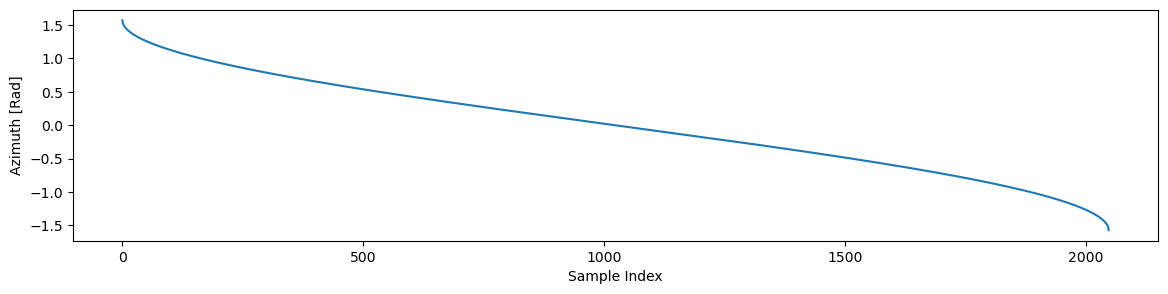

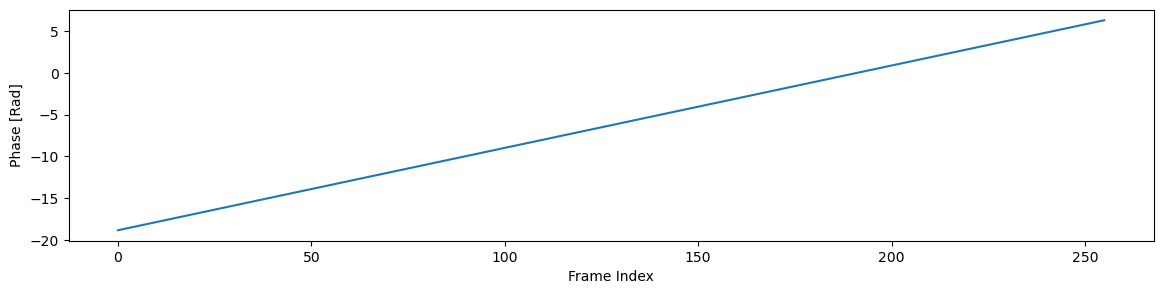

In [8]:
angle_sample = np.arccos(np.linspace(-1, 1, NUN_SAMPLE)) - np.pi/2
phase_frame  = np.linspace(-2 * np.pi * NUM_CYCLE, 2 * np.pi, NUM_FRAME)

# plot parameters
plt.figure(figsize=(14, 3))
plt.plot(angle_sample)
plt.xlabel('Sample Index')
plt.ylabel('Azimuth [Rad]')
plt.show();plt.clf();plt.close()
plt.figure(figsize=(14, 3))
plt.plot(phase_frame)
plt.xlabel('Frame Index')
plt.ylabel('Phase [Rad]')
plt.show();plt.clf();plt.close()


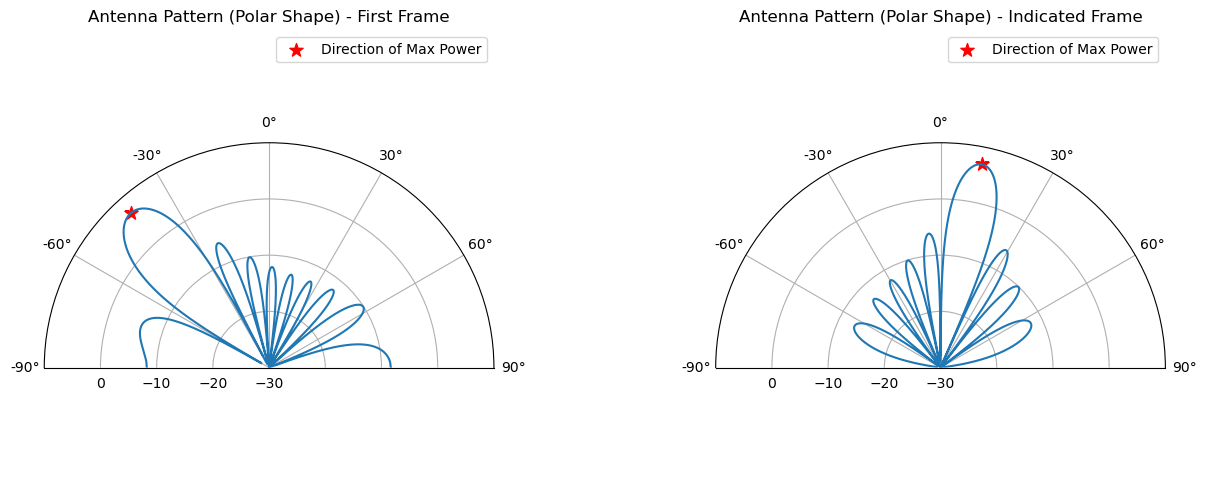

In [9]:

def calc_anttena_pattern(amp, phase):
    signal = np.conj(amp * np.exp(1j * phase))
    signal_sample = np.zeros(NUN_SAMPLE, dtype=np.complex64)
    signal_sample[:NUM_UNIT] = signal
    signal_sample_fft = np.fft.fftshift(np.fft.fft(signal_sample) * NUM_UNIT)
    signal_sample_dB = SCALE_AMP * np.log10((np.abs(signal_sample_fft)**2) / NUN_SAMPLE)
    return signal_sample_dB

# plot firts polar antenna pattern
fig = plt.figure(figsize=(14, 5))
for i, idx_plot in enumerate([121, 122]):
    ax = fig.add_subplot(idx_plot, projection='polar')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_thetamin(-90)
    ax.set_thetamax(90)
    ax.set_ylim([-25, 10])
    ax.set_yticks(np.arange(-30, 10, 10))
    
    if i == 0:
        ax.set_title("Antenna Pattern (Polar Shape) - First Frame")
        idx_frame_i = 0
    else:
        ax.set_title("Antenna Pattern (Polar Shape) - Indicated Frame")
        idx_frame_i = idx_frame
        
    element_phase = phase_frame[idx_frame_i] * np.linspace(0, 1, NUM_UNIT)
    signal_sample_dB = calc_anttena_pattern(1, element_phase)
    polar_plot, = ax.plot(angle_sample, signal_sample_dB)
    
    # max values
    idx_max = np.argmax(signal_sample_dB)
    ax.scatter(angle_sample[idx_max], signal_sample_dB[idx_max],  
               label='Direction of Max Power', color='red', s=100, marker='*')
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PATH_OUTPUT, 'antenna_pattern_polar.png'))
plt.show();plt.clf();plt.close()

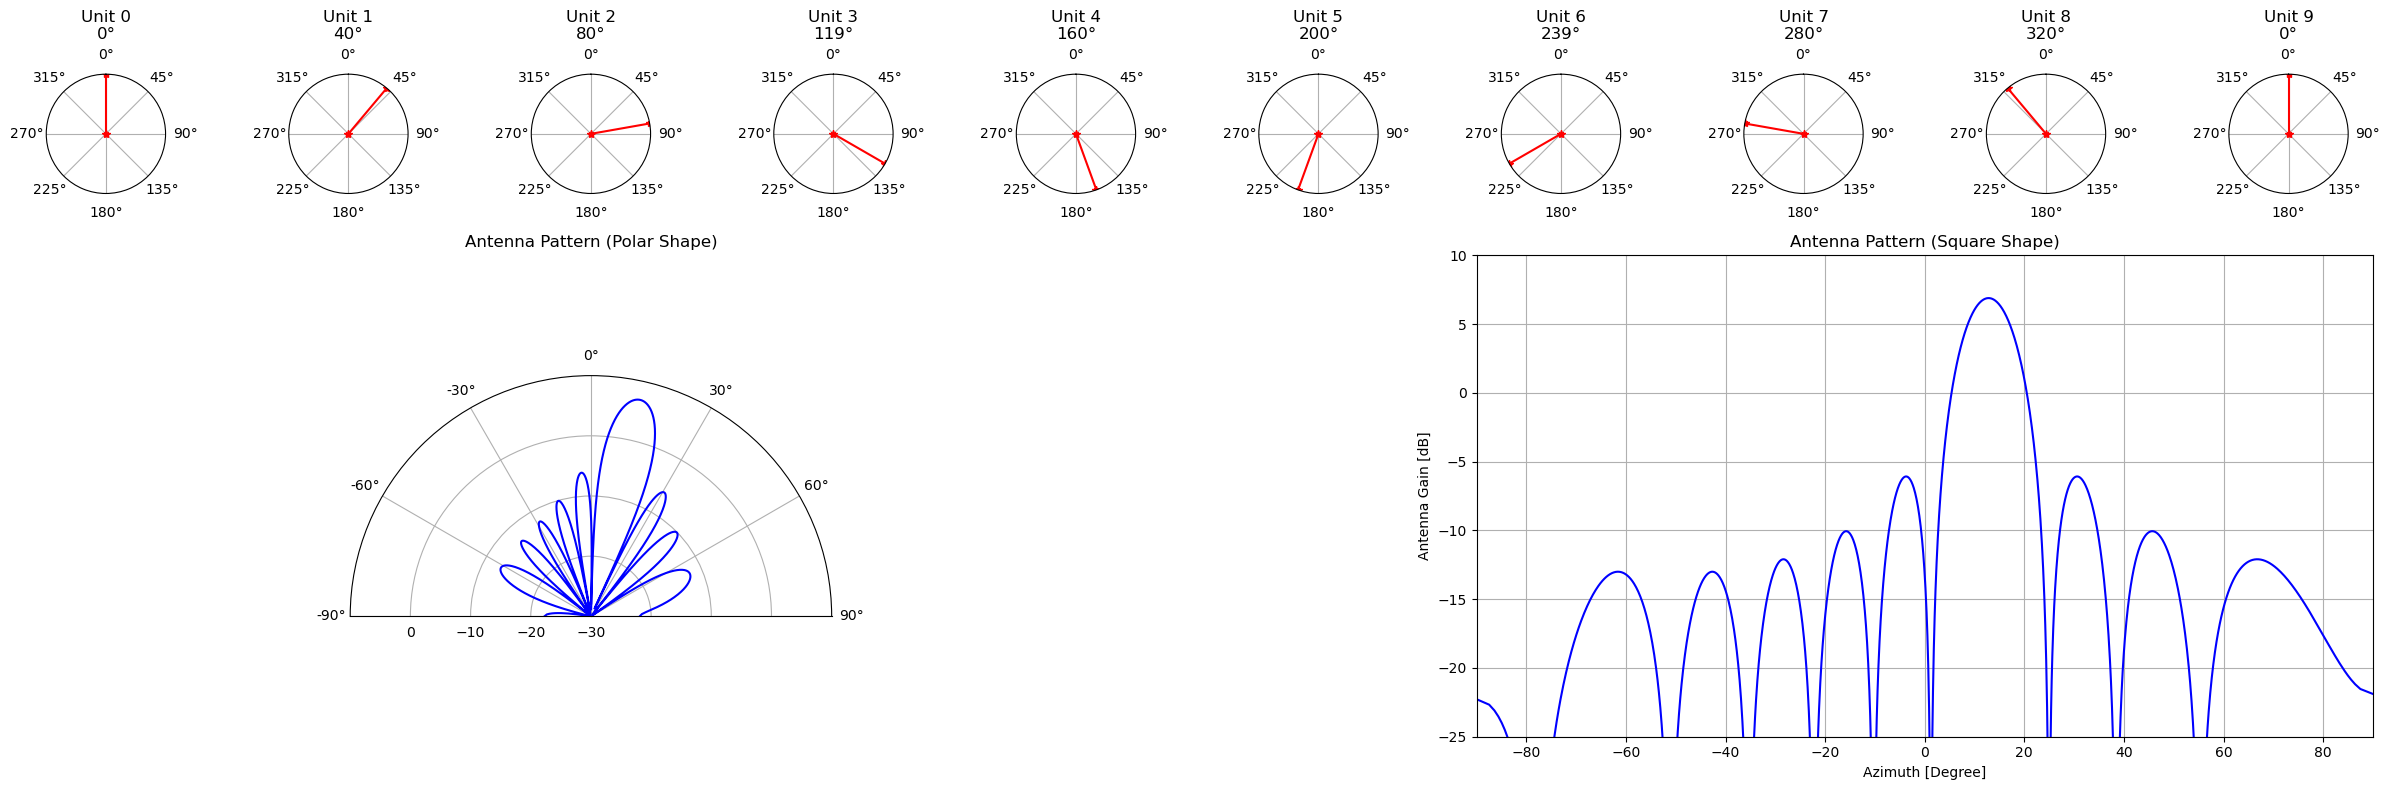

In [10]:
# animation loop
fig = plt.figure(figsize=(24, 8))
figgs = fig.add_gridspec(NUM_ROWS, NUM_COLS)

# plot polar unit
unit_axes = []
unit_plots = []

for i in range(NUM_UNIT):
    ax = fig.add_subplot(figgs[0, i], projection='polar')
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_xticklabels(["0°", "45°", "90°", "135°", "180°", "225°", "270°", "315°"])
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xticks(np.linspace(0, 2 * np.pi, 8, endpoint=False))
    ax.set_title(f"Unit {i}")
    unit_axes.append(ax)
    _plot = ax.plot([], [], 'or-', marker='*')[0]
    unit_plots.append(_plot)
    
# plot polar antenna pattern
ax2 = fig.add_subplot(figgs[1:4, :int(NUM_ROWS/2)+3], projection='polar')
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)
ax2.set_thetamin(-90)
ax2.set_thetamax(90)
ax2.set_ylim([-25, 10])
ax2.set_yticks(np.arange(-30, 10, 10))
ax2.set_title("Antenna Pattern (Polar Shape)")
polar_plot, = ax2.plot(angle_sample, signal_sample_dB, color='blue')

# plot square antenna pattern
ax3 = fig.add_subplot(figgs[1:4, int(NUM_ROWS/2)+4:])
ax3.set_xlim([-90, 90])
ax3.set_ylim([-25, 10])
ax3.set_xlabel("Azimuth [Degree]")
ax3.set_ylabel("Antenna Gain [dB]")
ax3.grid()
ax3.set_title("Antenna Pattern (Square Shape)")
rect_plot, = ax3.plot(angle_sample * 180 / np.pi, signal_sample_dB, color='blue')

def update(frame):
    element_phase = phase_frame[frame] * np.linspace(0, 1, NUM_UNIT)
    signal_sample_dB = calc_anttena_pattern(1, element_phase)
    
    for i, (ax, plot) in enumerate(zip(unit_axes, unit_plots)):
        plot.set_data([element_phase[i], element_phase[i]], [0, 1])
        ax.set_title(f"Unit {i}\n{int(np.degrees(element_phase[i]) % 360)}°")
    
    polar_plot.set_ydata(signal_sample_dB)
    rect_plot.set_ydata(signal_sample_dB)
    plt.tight_layout()
    return unit_plots + [polar_plot, rect_plot]


ani = FuncAnimation(fig, update, frames=NUM_FRAME, interval=100, blit=True)
writer = PillowWriter(fps=30)
PATH_GIF = os.path.join(PATH_OUTPUT, f'antenna_pattern_animation_f{NUM_FRAME}.gif')
ani.save(PATH_GIF, writer=writer)
plt.show();plt.clf();plt.close()